# 1. Read File CSV Dataset Training

In [1]:
import pandas as pd 

dataset_training =  pd.read_csv('dataset/training/dataset_training.csv')
dataset_training

,Tweet,label
0,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...",negative
1,"Sesama cewe lho (kayaknya), harusnya bisa lebi...",negative
2,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,positive
3,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...",negative
4,"Sharing pengalaman aja, kemarin jam 18.00 bata...",positive
...,...,...
59014,noelle loses a bet to akarsha and it somehow e...,neutral
59015,they call her... weekeeshee...\n#butterflysoup...,neutral
59016,"put out what you wanna see more of, amirite ga...",neutral
59017,"i don't need anybody, i'm fine here on my own\...",neutral


In [2]:
# count label

dataset_training['label'].value_counts()

label
positive    25679
neutral     18038
negative    15298
Name: count, dtype: int64

# 2. Exploration Data Analysis Dataset (EDA) Training

In [3]:
# split dataset_training to data_train and data_test (80:20)

from sklearn.model_selection import train_test_split

data_train, data_test = train_test_split(dataset_training, test_size=0.2, random_state=42)

In [6]:
# read data train

data_train

,Tweet,label
36580,jauhi lah perkara yang haram x elok \n\n#PPKM ...,negative
31436,Apakah rakyat kita menikmati kekayaan itu? Itu...,positive
28627,"Selama acara tersebut, sayap partai Gerindra j...",positive
6529,"Anies Basedan adalah kandidat presiden, Anda m...",positive
22529,Presiden Patanganjar Pranowo,negative
...,...,...
54343,"Pelan Pelan Kita Miskin ""PPKM""\n#PPKM https://...",negative
38158,PPKM di wilayah Jawa-Bali telah mengalami penu...,neutral
860,Gue punya Temen yg dibela-belain pinjem duwit ...,negative
15795,"Peneliti Senior Pusat Survei Indonesia, Chairu...",negative


In [7]:
data_train.shape

(47215, 2)

In [8]:
data_test

,Tweet,label
49313,Aksi unjuk rasa dari Literasi Pemuda Bandung d...,neutral
52925,Pak Presiden Kapan Mundur #PPKM #PPKMDarurat #...,neutral
44122,"Sejak pandemi berlangsung tahun 2020 lalu, PT ...",neutral
42895,Airlangga pun meminta seluruh Kepala Daerah di...,neutral
13717,Koalisi Jokowi memanaskan isu perombakan kabin...,negative
...,...,...
3049,sini berobat sama saya ini ngantri dokter saja...,negative
6217,"Djoe cuma bikin sate, orang ini bikin sup dari...",positive
26443,opik inismyname fahnoor allah menguji saya den...,positive
49,Ku rindu bisik mu di telingaku Seraya kau berk...,positive


In [9]:
data_test.shape

(11804, 2)

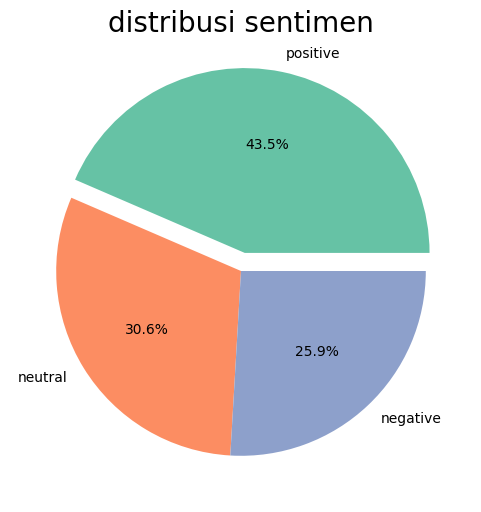

In [10]:
# look distribution label in dataset training use pie chart

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize = (6, 6))
sizes = [count for count in dataset_training['label'].value_counts()]
labels = list(data_train['label'].value_counts().index)
explode = (0.1, 0, 0)  # Offset the first segment

# Use color palet Seaborn
colors = sns.color_palette('Set2')
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, colors=colors, textprops={'fontsize': 10})
ax.set_title('distribusi sentimen', fontsize = 20)
plt.show()

Text(0.5, 1.0, 'Distribution of sentiment in training data')

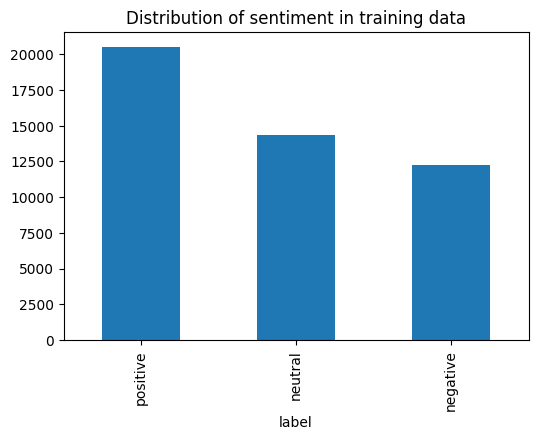

In [11]:
# look distribution label in data train use bar chart

plt.figure(figsize = (6,4))
data_train.label.value_counts().plot(kind = 'bar')
plt.title('Distribution of sentiment in training data')

Text(0.5, 1.0, 'Distribution of sentiment in testing data')

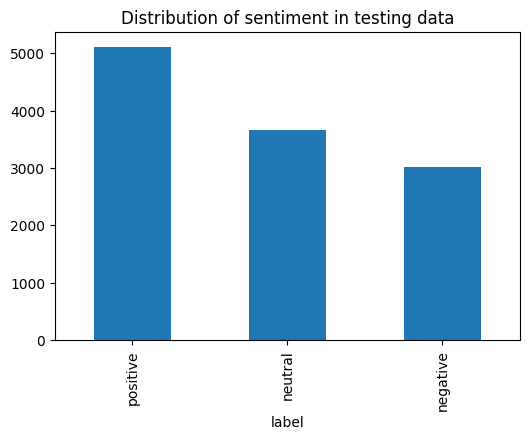

In [12]:
# look distribution label in data testing use bar chart

plt.figure(figsize = (6,4))
data_test.label.value_counts().plot(kind = 'bar')
plt.title('Distribution of sentiment in testing data')

## 2.1 Word Cloud

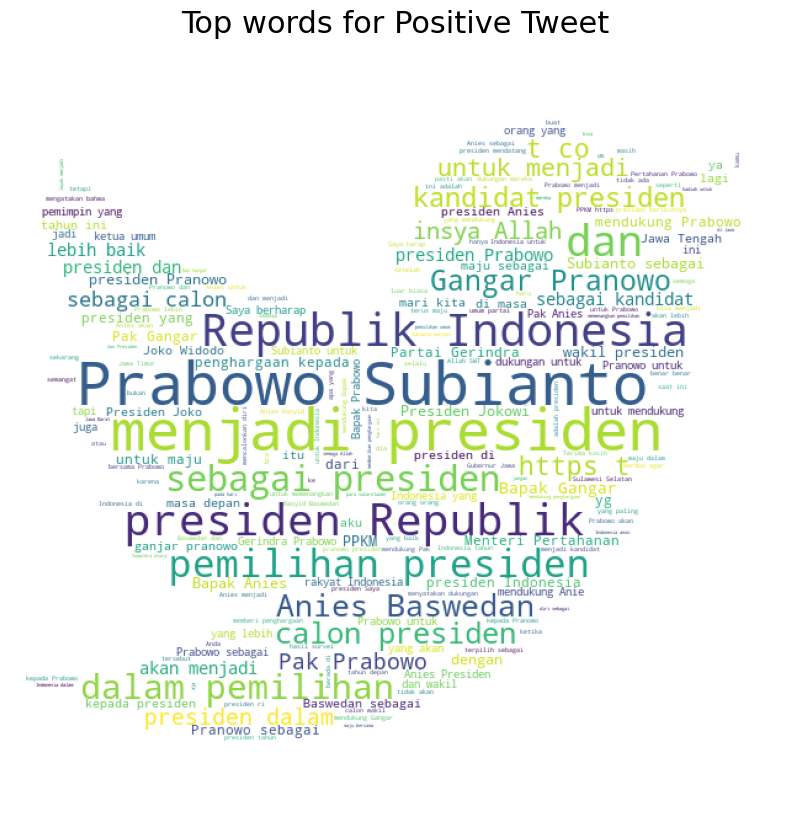

In [13]:
import requests
from PIL import Image
from io import BytesIO
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import numpy as np

url = "https://image.freepik.com/free-icon/twitter-logo_318-40459.jpg"  # replace with your image URL
response = requests.get(url)
twitter_mask = np.array(Image.open(BytesIO(response.content)))

wc = WordCloud(
    background_color='white',
    max_words=200,
    mask=twitter_mask,
)
wc.generate(' '.join(text for text in dataset_training.loc[dataset_training['label'] == 'positive', 'Tweet']))
plt.figure(figsize=(18,10))
plt.title('Top words for Positive Tweet',
          fontdict={'size': 22,  'verticalalignment': 'bottom'})
plt.imshow(wc)
plt.axis("off")
plt.show()

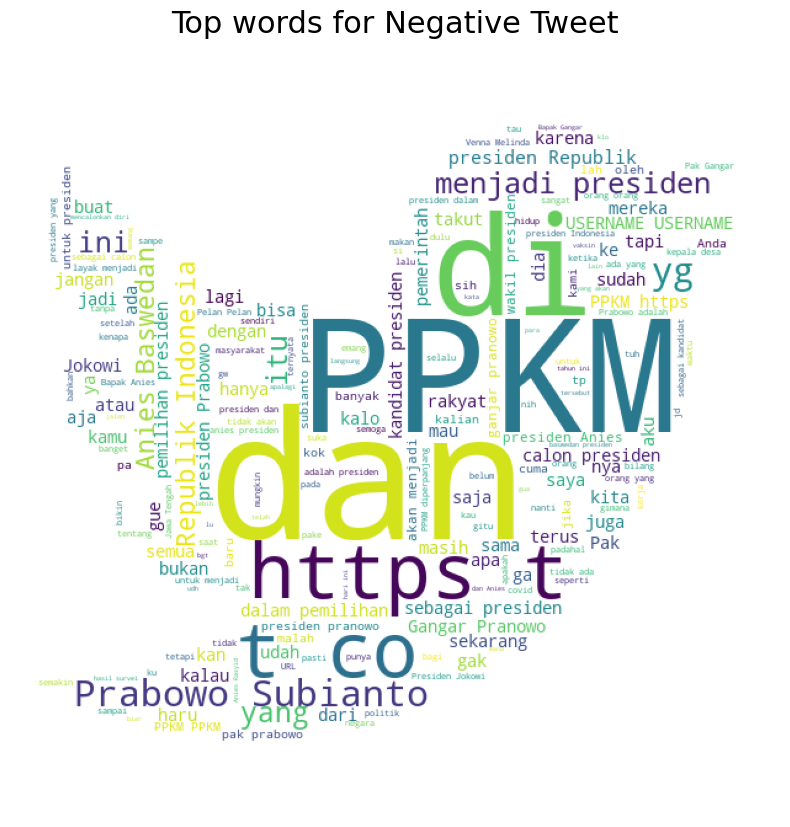

In [14]:
wc = WordCloud(
    background_color='white',
    max_words=200,
    mask=twitter_mask,
)
wc.generate(' '.join(text for text in dataset_training.loc[dataset_training['label'] == 'negative', 'Tweet']))
plt.figure(figsize=(18,10))
plt.title('Top words for Negative Tweet',
          fontdict={'size': 22,  'verticalalignment': 'bottom'})
plt.imshow(wc)
plt.axis("off")
plt.show()

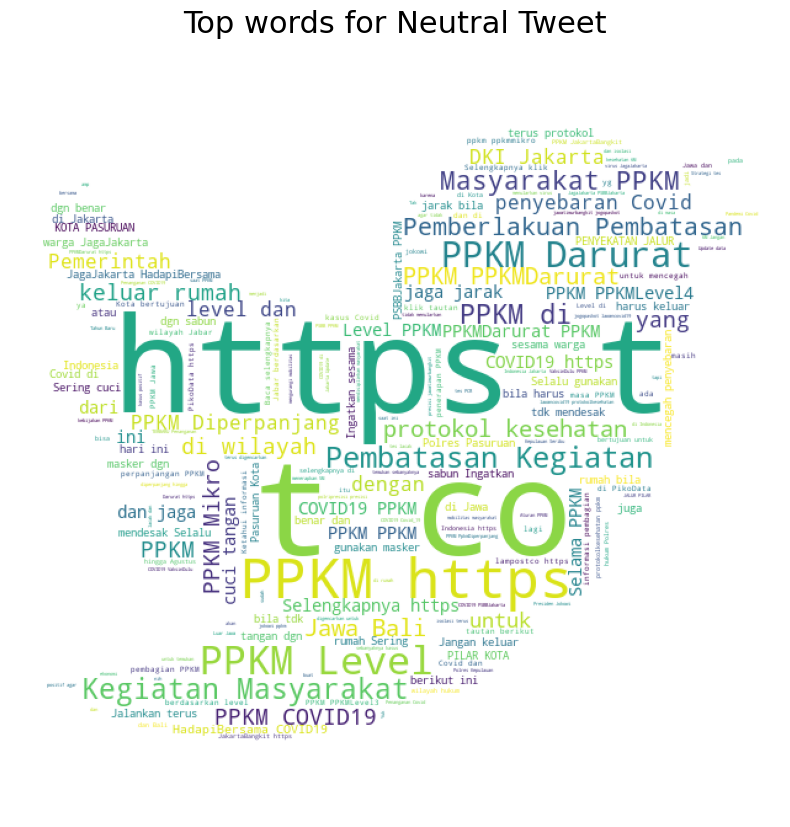

In [15]:
wc = WordCloud(
    background_color='white',
    max_words=200,
    mask=twitter_mask,
)
wc.generate(' '.join(text for text in dataset_training.loc[dataset_training['label'] == 'neutral', 'Tweet']))
plt.figure(figsize=(18,10))
plt.title('Top words for Neutral Tweet',
          fontdict={'size': 22,  'verticalalignment': 'bottom'})
plt.imshow(wc)
plt.axis("off")
plt.show()

In [16]:
# split coloumn in data_train and data_test

X_train = data_train['Tweet']
y_train = data_train['label']

X_test = data_test['Tweet']
y_test = data_test['label']

In [17]:
X_train

36580    jauhi lah perkara yang haram x elok \n\n#PPKM ...
31436    Apakah rakyat kita menikmati kekayaan itu? Itu...
28627    Selama acara tersebut, sayap partai Gerindra j...
6529     Anies Basedan adalah kandidat presiden, Anda m...
22529                         Presiden Patanganjar Pranowo
                               ...                        
54343    Pelan Pelan Kita Miskin "PPKM"\n#PPKM https://...
38158    PPKM di wilayah Jawa-Bali telah mengalami penu...
860      Gue punya Temen yg dibela-belain pinjem duwit ...
15795    Peneliti Senior Pusat Survei Indonesia, Chairu...
56422    PPKM 3 PILAR KOTA PASURUAN\n\nPemberlakuan Pem...
Name: Tweet, Length: 47215, dtype: str

In [18]:
y_train

36580    negative
31436    positive
28627    positive
6529     positive
22529    negative
           ...   
54343    negative
38158     neutral
860      negative
15795    negative
56422     neutral
Name: label, Length: 47215, dtype: str

In [19]:
X_test

49313    Aksi unjuk rasa dari Literasi Pemuda Bandung d...
52925    Pak Presiden Kapan Mundur #PPKM #PPKMDarurat #...
44122    Sejak pandemi berlangsung tahun 2020 lalu, PT ...
42895    Airlangga pun meminta seluruh Kepala Daerah di...
13717    Koalisi Jokowi memanaskan isu perombakan kabin...
                               ...                        
3049     sini berobat sama saya ini ngantri dokter saja...
6217     Djoe cuma bikin sate, orang ini bikin sup dari...
26443    opik inismyname fahnoor allah menguji saya den...
49       Ku rindu bisik mu di telingaku Seraya kau berk...
42397    Jika kita sangat ketat menjaga prokes agar ter...
Name: Tweet, Length: 11804, dtype: str

In [20]:
y_test

49313     neutral
52925     neutral
44122     neutral
42895     neutral
13717    negative
           ...   
3049     negative
6217     positive
26443    positive
49       positive
42397    negative
Name: label, Length: 11804, dtype: str

# 3. Data Preprocessing

In [21]:
import openpyxl

# read file stopword_bahasa_indonesia

stopword_indonesia = pd.read_csv('dataset/text_normalization/stopword_bahasa_indonesia.csv')

# read file kamus gaul, typo, singkatan indonesia

dictionary_indonesia = pd.read_excel('dataset/text_normalization/kamus_singkatan_typo_gaul_indonesia.xlsx')

In [22]:
stopword_indonesia

,ada
0,adalah
1,adanya
2,adapun
3,agak
4,agaknya
...,...
752,wong
753,yaitu
754,yakin
755,yakni


In [23]:
dictionary_indonesia

,original,replacement
0,aaamiiinnn,amin
1,aamiiin,amin
2,aamiin,amin
3,aamiin,amin
4,abgmu,kakakmu
...,...,...
1120,yg,yang
1121,yha,ya
1122,yme,yang maha esa
1123,yutub,youtube


## 3.1 Cleaning

In [24]:
# import library

import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import nltk
from nltk.tokenize import word_tokenize

In [25]:
class TextCleaner:

    # init
    def __init__(self, dictionary_df, stopword_df, remove_words=None):
        # Inisialisasi Sastrawi sekali saja agar cepat
        self.factory = StemmerFactory()
        self.stemmer = self.factory.create_stemmer()
        
        # Konversi Kamus Normalisasi ke Dictionary murni
        self.dictionary_map = dict(zip(dictionary_df['original'], dictionary_df['replacement']))
        
        # Konversi Stopword ke Set untuk pencarian cepat
        self.stop_set = set(stopword_indonesia.ada.values)
        
        # List kata spesifik yang ingin dihapus total
        self.remove_words = remove_words if remove_words else []
        
        # Kamus Kata Majemuk untuk digabung sebelum stemming
        self.compound_map = {
            r'\borang\s+tua\b': 'orangtua',
            r'\bterima\s+kasih\b': 'terimakasih',
            r'\btanggung\s+jawab\b': 'tanggungjawab',
            r'\bkerja\s+sama\b': 'kerjasama',
            r'\bsering\s+kali\b': 'seringkali',
            r'\bapa\s+pun\b': 'apapun',
            r'\bbagaimana\s+pun\b': 'bagaimanapun'
        }
    
    # function remove character
    def _remove_unnecessary_char(self, text):
        text = text.lower()
        
        # 1. TANGANI KATA ULANG ANGKA (jalan2 -> jalan jalan, ada2saja -> ada ada saja)
        # Mencari kata yang diikuti angka 2, lalu diulang kata tersebut
        text = re.sub(r'\b(\w+)2\b', r'\1 \1', text)
        
        # 2. HAPUS HASHTAG, USERNAME, URL
        text = re.sub(r'#\w+', ' ', text)
        text = re.sub(r'@[A-Za-z0-9_]+', ' ', text) 
        text = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))', ' ', text)
        
        # 3. NORMALISASI HURUF BERULANG (mbuuuhh -> mbuh)
        text = re.sub(r'(.)\1{2,}', r'\1', text)
        
        # 4. HAPUS SIMBOL (Ini otomatis menangani "(barang" -> "barang")
        # Menghapus semua yang bukan huruf dan angka, termasuk kurung dan kutip
        text = re.sub(r'[^0-9a-zA-Z]+', ' ', text)
        
        # 5. HAPUS KATA SPESIFIK (remove_words)
        for word in self.remove_words:
            text = re.sub(r'\b' + word + r'\b', ' ', text)
        return text

    # function fix compound words
    def _fix_compound_words(self, text):
        for pattern, replacement in self.compound_map.items():
            text = re.sub(pattern, replacement, text)
        return text

    # function normalize indonesian word
    def _normalize_indonesian(self, text):
        return ' '.join([self.dictionary_map.get(word, word) for word in text.split()])

    # function remove stopwords
    def _remove_stopwords(self, text):
        return ' '.join([word for word in text.split() if word not in self.stop_set])

    # funtion stemming
    def _stemming(self, text):
        # Tokenize dulu sebelum di-stem
        tokens = word_tokenize(text)
        return ' '.join([self.stemmer.stem(w) for w in tokens])

    # function full process
    def full_process(self, text):
        if not isinstance(text, str): return ""
        
        # Urutan: Karakter -> Normalisasi Alay -> Gabung Majemuk -> Stopword -> Stemming
        text = self._remove_unnecessary_char(text)
        text = self._normalize_indonesian(text)
        text = self._fix_compound_words(text)
        text = self._remove_stopwords(text)
        text = self._stemming(text)
        
        return re.sub(r'  +', ' ', text).strip()

In [26]:

# list remove words
target_remove = [
    'username', 'ppkm', 'covid', 'covid19', 'corona', 'pandemi', 'pemerintah', 'jokowi', 
    'prabowo', 'subianto', 'ganjar', 'gangar', 'pranowo',
    'anies', 'baswedan', 'gibran', 'rakabuming', 'mahfud', 'muhaimin', 'iskandar', 'pilpres', 'pemilu', 
    'banjir', 'sumatra', 'presiden', 'gubernur', 'joko', 'widodo', 
]

In [27]:

# initialize class
# Pastikan variabel dictionary_indonesia & stopword_indonesia sudah di-load sebelumnya
cleaner = TextCleaner(dictionary_indonesia, stopword_indonesia, remove_words=target_remove)

In [28]:
# run on dataframe
# Disarankan simpan ke kolom baru (misal: 'text_cleaned') agar data asli tetap ada
x_cleaning_train = X_train.apply(cleaner.full_process)
x_cleaning_train.head()

36580                         jauh perkara haram x elok
31436                       rakyat nikmat kaya gerindra
28627    acara sayap partai gerindra dukung calon pilih
6529                              basedan kandidat erti
22529                                       patanganjar
Name: Tweet, dtype: str

In [31]:
# make attribut for x_cleaning_train

data_train['text_cleaned'] = x_cleaning_train
data_train = data_train[['Tweet', 'text_cleaned', 'label']]
data_train

,Tweet,text_cleaned,label
36580,jauhi lah perkara yang haram x elok \n\n#PPKM ...,jauh perkara haram x elok,negative
31436,Apakah rakyat kita menikmati kekayaan itu? Itu...,rakyat nikmat kaya gerindra,positive
28627,"Selama acara tersebut, sayap partai Gerindra j...",acara sayap partai gerindra dukung calon pilih,positive
6529,"Anies Basedan adalah kandidat presiden, Anda m...",basedan kandidat erti,positive
22529,Presiden Patanganjar Pranowo,patanganjar,negative
...,...,...,...
54343,"Pelan Pelan Kita Miskin ""PPKM""\n#PPKM https://...",pelan pelan miskin,negative
38158,PPKM di wilayah Jawa-Bali telah mengalami penu...,wilayah jawa bal alami turun level dampak sala...,neutral
860,Gue punya Temen yg dibela-belain pinjem duwit ...,temen bela bain pinjem uang kantor nyawer tunj...,negative
15795,"Peneliti Senior Pusat Survei Indonesia, Chairu...",teliti senior pusat survei indonesia chairul a...,negative


In [32]:
# save dataframe to csv

data_train.to_csv('data_train_clean.csv', index=False)

In [33]:
# run on dataframe
# Disarankan simpan ke kolom baru (misal: 'text_cleaned') agar data asli tetap ada
x_cleaning_test = X_test.apply(cleaner.full_process)
x_cleaning_test.head()

49313    aksi unjuk literasi pemuda bandung ojek online...
52925                                               mundur
44122    2020 pt federal international finance fifgroup...
42895    airlangga kepala daerah sulawesi tingkat testi...
13717    koalisi panas isu ombak kabinet terima nama gu...
Name: Tweet, dtype: str

In [34]:
# make attribut for x_cleaning_train

data_test['text_cleaned'] = x_cleaning_test
data_test = data_test[['Tweet', 'text_cleaned', 'label']]
data_test

,Tweet,text_cleaned,label
49313,Aksi unjuk rasa dari Literasi Pemuda Bandung d...,aksi unjuk literasi pemuda bandung ojek online...,neutral
52925,Pak Presiden Kapan Mundur #PPKM #PPKMDarurat #...,mundur,neutral
44122,"Sejak pandemi berlangsung tahun 2020 lalu, PT ...",2020 pt federal international finance fifgroup...,neutral
42895,Airlangga pun meminta seluruh Kepala Daerah di...,airlangga kepala daerah sulawesi tingkat testi...,neutral
13717,Koalisi Jokowi memanaskan isu perombakan kabin...,koalisi panas isu ombak kabinet terima nama gu...,negative
...,...,...,...
3049,sini berobat sama saya ini ngantri dokter saja...,obat ngantri dokter kek ngantri sembako bener,negative
6217,"Djoe cuma bikin sate, orang ini bikin sup dari...",djoe bikin sate orang bikin sup tulang rezim g...,positive
26443,opik inismyname fahnoor allah menguji saya den...,opik inismyname fahnoor allah uji presiden,positive
49,Ku rindu bisik mu di telingaku Seraya kau berk...,rindu bisik mu telinga seraya kau moga kelak k...,positive


In [35]:
# save dataframe to csv

data_test.to_csv('data_test_clean.csv', index=False)